Description:

- Code | Description
- MEMBER_NO-b : Member ID
- FFP_DATE : Frequent Flyer Program Join Date
- FIRST_FLIGHT_DATE : First Flight Date
- GENDER : Gender
- FFP_TIER : Tier of the Frequent Flyer Program
- WORK_CITY : City of Origin
- WORK_PROVINCE : Province of Origin
- WORK_COUNTRY : Country of Origin
- AGE : Customer Age
- LOAD_TIME : Date the data was retrieved
- FLIGHT_COUNT : Number of flights by the customer
- BP_SUM : Travel Plan
- SUM_YR_1 : Total credit/points in the first year
- SUM_YR_2 : Total credit/points in the second year
- SEG_KM_SUM : Total flight distance (km) already traveled
- LAST_FLIGHT_DATE : Last Flight Date
- LAST_TO_END : Time interval from the last flight to the latest flight booking
- AVG_INTERVAL : Average time interval
- MAX_INTERVAL : Maximum time interval
- EXCHANGE_COUNT : Number of redemptions
- avg_discount : Average discount received by the customer
- Points_Sum : Total points earned by the customer
- Point_NotFlight : Points not used by members

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [30]:
df = pd.read_csv('flight.csv')
df.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,210,505308,239560.0,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,28065,2/19/2007,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,140,362480,171483.0,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,135,351159,163618.0,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,23,337314,116350.0,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,39546,4/10/2009,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,152,273844,124560.0,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


In [31]:
print(df.shape)
print('_________________')
print(df.info())
print('_________________')
print(df.isna().sum())
print('_________________')
print(df.duplicated().sum())
print('_________________')

(62988, 23)
_________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   62988 non-null  objec

## Pre Processing

In [32]:
# filling missing values
df['AGE'] = df['AGE'].fillna(df['AGE'].median())
df['SUM_YR_1'] = df['SUM_YR_1'].fillna(df['SUM_YR_1'].median())
df['SUM_YR_2'] = df['SUM_YR_2'].fillna(df['SUM_YR_2'].median())

In [33]:
# work city, work province, work country mostly in china, so we drop them
df = df.drop(columns=['MEMBER_NO', 'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY'])
df = df.dropna()

In [34]:
df.isna().sum()

FFP_DATE             0
FIRST_FLIGHT_DATE    0
GENDER               0
FFP_TIER             0
AGE                  0
LOAD_TIME            0
FLIGHT_COUNT         0
BP_SUM               0
SUM_YR_1             0
SUM_YR_2             0
SEG_KM_SUM           0
LAST_FLIGHT_DATE     0
LAST_TO_END          0
AVG_INTERVAL         0
MAX_INTERVAL         0
EXCHANGE_COUNT       0
avg_discount         0
Points_Sum           0
Point_NotFlight      0
dtype: int64

In [35]:
df.describe()

,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
count,62985.000000,62985.000000,62985.000000,62985.000000,62985.000000,62985.000000,62985.000000,62985.000000,62985.000000,62985.000000,62985.000000,62985.000000,62985.000000,62985.000000
mean,4.102135,42.465889,11.839501,10923.206509,5332.614913,5596.579535,17122.760102,176.121902,67.751101,166.035786,0.319759,0.721547,12543.607938,2.728237
std,0.373788,9.853283,14.049756,16332.283621,8076.971956,8688.584817,20958.333748,183.821977,77.519373,123.398937,1.136010,0.185412,20499.958442,7.364323
min,4.000000,6.000000,2.000000,0.000000,0.000000,0.000000,368.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,35.000000,3.000000,2518.000000,1020.000000,785.000000,4747.000000,29.000000,23.370370,79.000000,0.000000,0.612000,2775.000000,0.000000
50%,4.000000,41.000000,7.000000,5700.000000,2800.000000,2773.000000,9994.000000,108.000000,44.666667,143.000000,0.000000,0.711856,6328.000000,0.000000
75%,4.000000,48.000000,15.000000,12831.000000,6523.000000,6826.000000,21271.000000,268.000000,82.000000,228.000000,0.000000,0.809469,14302.000000,1.000000
max,6.000000,110.000000,213.000000,505308.000000,239560.000000,234188.000000,580717.000000,731.000000,728.000000,728.000000,46.000000,1.500000,985572.000000,140.000000


In [36]:
df.head()

,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,11/2/2006,12/24/2008,Male,6,31.0,3/31/2014,210,505308,239560.0,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,2/19/2007,8/3/2007,Male,6,42.0,3/31/2014,140,362480,171483.0,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,2/1/2007,8/30/2007,Male,6,40.0,3/31/2014,135,351159,163618.0,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,8/22/2008,8/23/2008,Male,5,64.0,3/31/2014,23,337314,116350.0,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,4/10/2009,4/15/2009,Male,6,48.0,3/31/2014,152,273844,124560.0,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


In [37]:
df['FFP_DATE'] = pd.to_datetime(df['FFP_DATE'])
df['FIRST_FLIGHT_DATE'] = pd.to_datetime(df['FIRST_FLIGHT_DATE'])
df['LOAD_TIME'] = pd.to_datetime(df['LOAD_TIME'])

In [38]:
df.isna().sum()

FFP_DATE             0
FIRST_FLIGHT_DATE    0
GENDER               0
FFP_TIER             0
AGE                  0
LOAD_TIME            0
FLIGHT_COUNT         0
BP_SUM               0
SUM_YR_1             0
SUM_YR_2             0
SEG_KM_SUM           0
LAST_FLIGHT_DATE     0
LAST_TO_END          0
AVG_INTERVAL         0
MAX_INTERVAL         0
EXCHANGE_COUNT       0
avg_discount         0
Points_Sum           0
Point_NotFlight      0
dtype: int64

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62985 entries, 0 to 62987
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   FFP_DATE           62985 non-null  datetime64[ns]
 1   FIRST_FLIGHT_DATE  62985 non-null  datetime64[ns]
 2   GENDER             62985 non-null  object        
 3   FFP_TIER           62985 non-null  int64         
 4   AGE                62985 non-null  float64       
 5   LOAD_TIME          62985 non-null  datetime64[ns]
 6   FLIGHT_COUNT       62985 non-null  int64         
 7   BP_SUM             62985 non-null  int64         
 8   SUM_YR_1           62985 non-null  float64       
 9   SUM_YR_2           62985 non-null  float64       
 10  SEG_KM_SUM         62985 non-null  int64         
 11  LAST_FLIGHT_DATE   62985 non-null  object        
 12  LAST_TO_END        62985 non-null  int64         
 13  AVG_INTERVAL       62985 non-null  float64       
 14  MAX_INTERVA

In [40]:
df.head()

,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,AGE,LOAD_TIME,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,2006-11-02,2008-12-24,Male,6,31.0,2014-03-31,210,505308,239560.0,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,2007-02-19,2007-08-03,Male,6,42.0,2014-03-31,140,362480,171483.0,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,2007-02-01,2007-08-30,Male,6,40.0,2014-03-31,135,351159,163618.0,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,2008-08-22,2008-08-23,Male,5,64.0,2014-03-31,23,337314,116350.0,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,2009-04-10,2009-04-15,Male,6,48.0,2014-03-31,152,273844,124560.0,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


# Feature selection

LRFMC is a method that can be used for customer segmentation in airlines. L stands for loyalty, R for recency, F for frequency, M for monetary value, and C for category (discount). <br>
Based on the LRFMC model, six features related to the LRFMC index model are selected:  <br>
- Length: LOAD_TIME - FFP_DATE
- Recency: LAST_TO_END
- Frequency: FLIGHT_COUNT
- Monetary: SEG_KM_FM
- Customer Cost: avg_discount

In [41]:
data = df[['FFP_DATE', 'LOAD_TIME', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'avg_discount']]

In [42]:
data['Length'] = data['LOAD_TIME'] - data['FFP_DATE']
data['Length'] = data['Length'].dt.days

data.drop(columns=['LOAD_TIME', 'FFP_DATE'], inplace=True)




C:\Users\BUDI\AppData\Local\Temp\ipykernel_17324\1312747626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Length'] = data['LOAD_TIME'] - data['FFP_DATE']
C:\Users\BUDI\AppData\Local\Temp\ipykernel_17324\1312747626.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Length'] = data['Length'].dt.days
C:\Users\BUDI\AppData\Local\Temp\ipykernel_17324\1312747626.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation

In [43]:
data.rename(columns={
    "LAST_TO_END": "R",
    "FLIGHT_COUNT": "F",
    "SEG_KM_SUM": "M",
    "avg_discount": "C",
    "Length": "L"
}, inplace=True)

columns = ["L", "R", "F", "M", "C"]
data = data[columns]

print(data.head())

      L   R    F       M         C
0  2706   1  210  580717  0.961639
1  2597   7  140  293678  1.252314
2  2615  11  135  283712  1.254676
3  2047  97   23  281336  1.090870
4  1816   5  152  309928  0.970658


C:\Users\BUDI\AppData\Local\Temp\ipykernel_17324\1831309243.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.rename(columns={


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62985 entries, 0 to 62987
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   L       62985 non-null  int64  
 1   R       62985 non-null  int64  
 2   F       62985 non-null  int64  
 3   M       62985 non-null  int64  
 4   C       62985 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 2.9 MB


## EDA

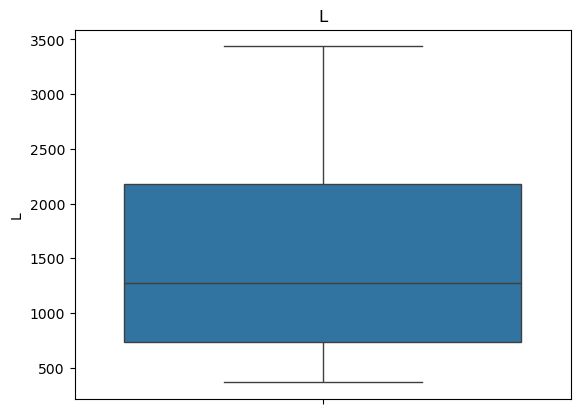

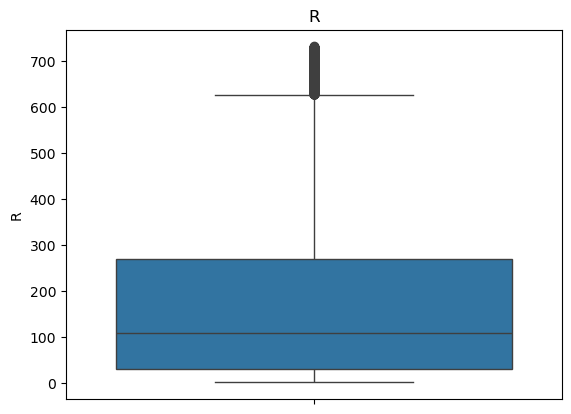

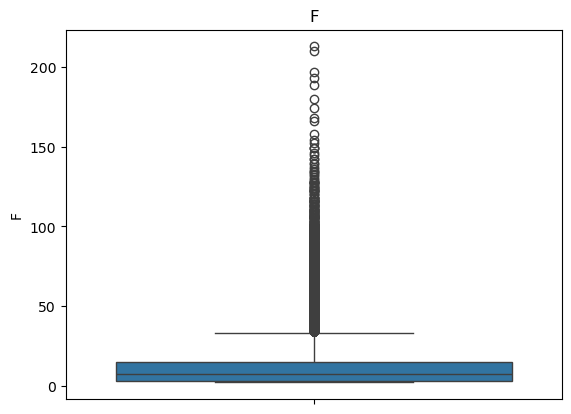

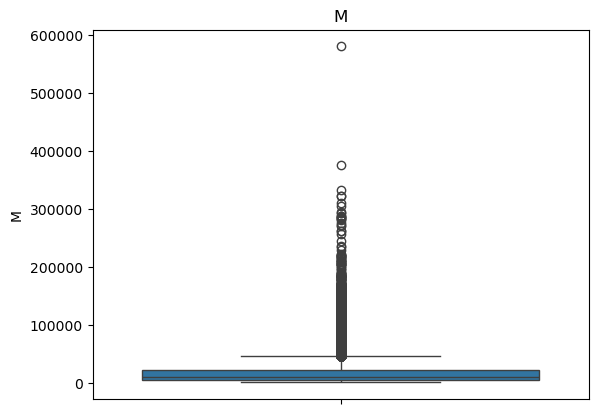

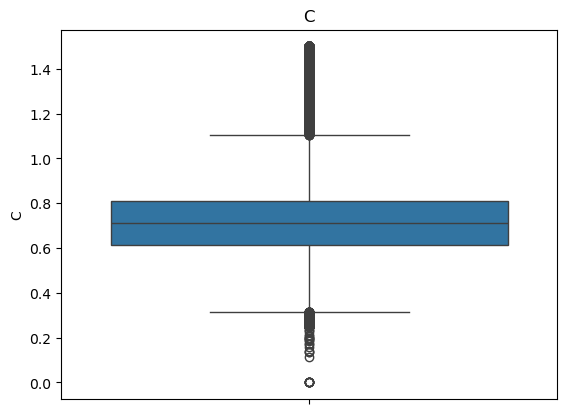

In [45]:
for col in data.columns:
    sns.boxplot(data[col])
    plt.title(col)
    plt.show()

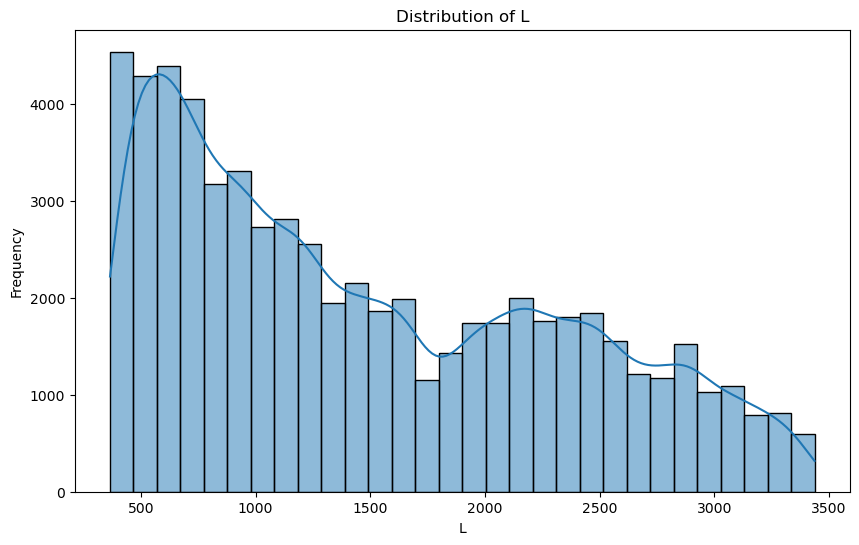

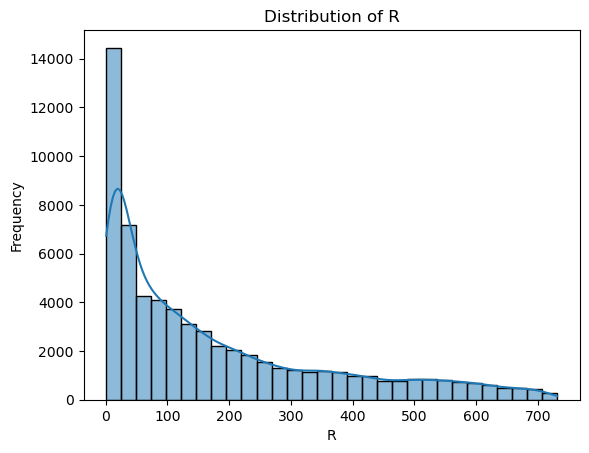

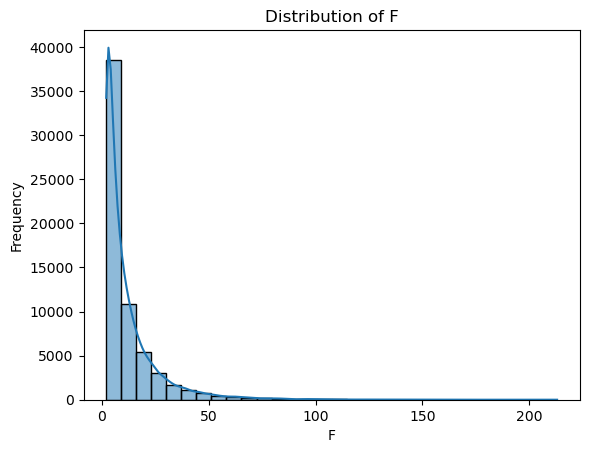

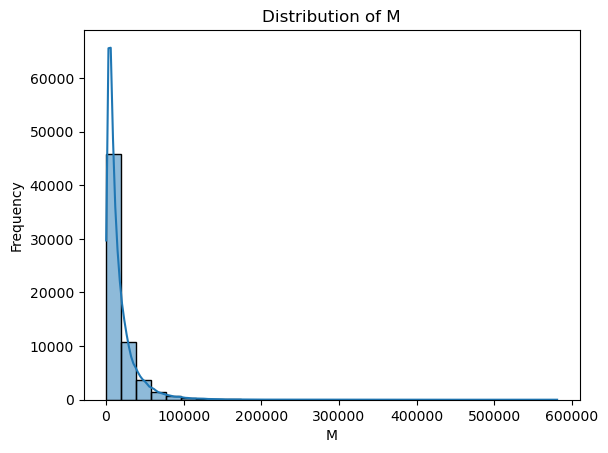

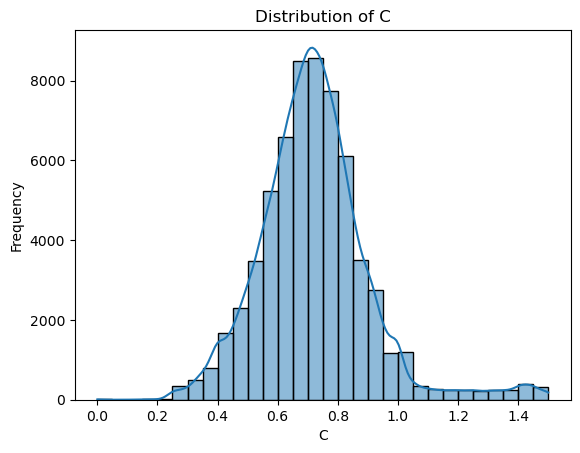

In [46]:
plt.figure(figsize=(10, 6))
for col in data.columns:
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


## Modelling

In [47]:
data.head()

,L,R,F,M,C
0,2706,1,210,580717,0.961639
1,2597,7,140,293678,1.252314
2,2615,11,135,283712,1.254676
3,2047,97,23,281336,1.090870
4,1816,5,152,309928,0.970658


          L         R         F         M         C
0  0.762044  0.000000  0.985782  1.000000  0.641093
1  0.726562  0.008219  0.654028  0.505403  0.834876
2  0.732422  0.013699  0.630332  0.488230  0.836450
3  0.547526  0.131507  0.099526  0.484136  0.727246
4  0.472331  0.005479  0.710900  0.533403  0.647105


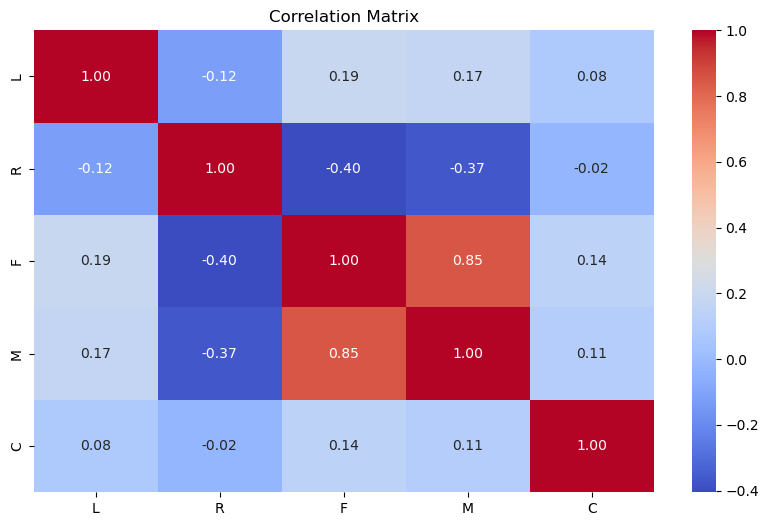

In [48]:
# Min max scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
print(data_scaled.head())
# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(data_scaled.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

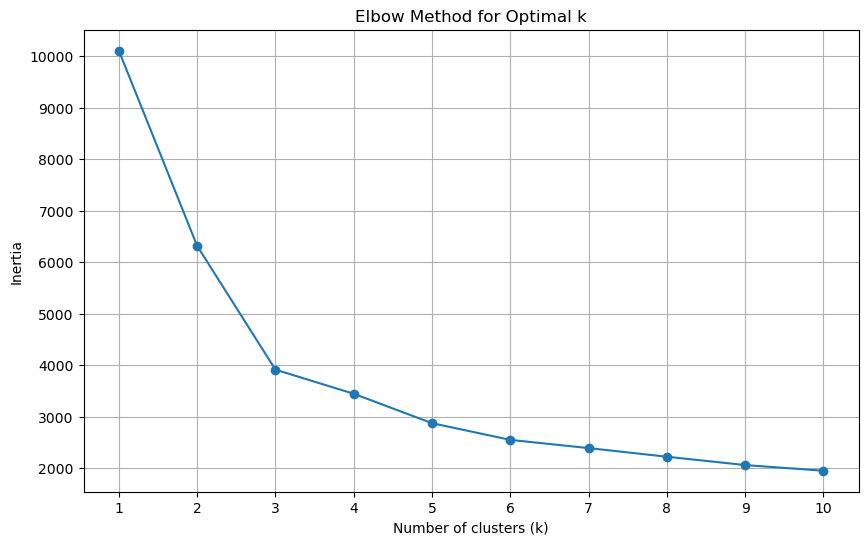

In [49]:
# Elbow method for optimal number of clusters
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid()
plt.show()

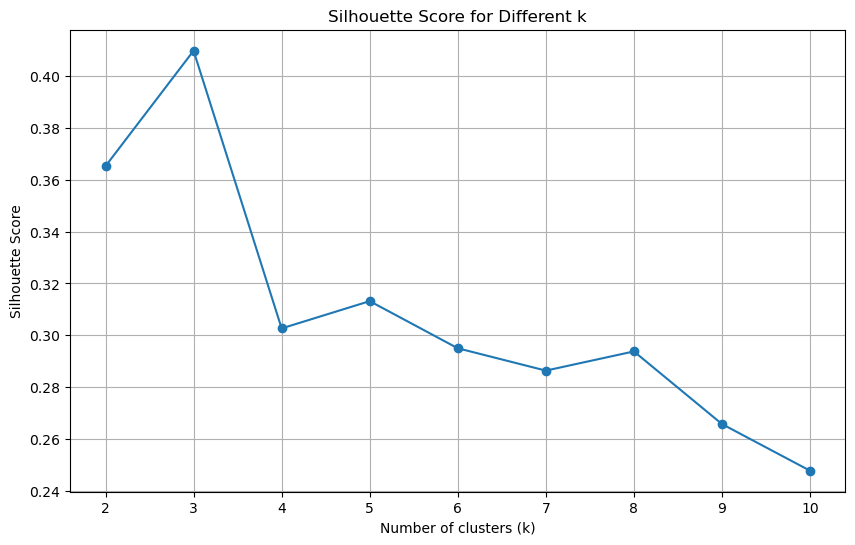

In [50]:
# silhouette score
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    score = silhouette_score(data_scaled, kmeans.labels_)
    silhouette_scores.append(score)
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid()
plt.show()

In [51]:
# KMeans clustering with optimal k
baseline_k = 3
kmeans_baseline = KMeans(n_clusters=baseline_k, random_state=42)
kmeans_baseline.fit(data_scaled)
baseline_labels = kmeans_baseline.labels_

# Print cluster centers and inertia
print("Cluster Centers:\n", kmeans_baseline.cluster_centers_)
print("Inertia:", kmeans_baseline.inertia_)

Cluster Centers:
 [[0.18206489 0.12725549 0.04929156 0.03025939 0.47422428]
 [0.26793882 0.65759546 0.0098461  0.01043023 0.47685814]
 [0.69290676 0.137049   0.06629053 0.03864155 0.49363966]]
Inertia: 3911.4434052830193


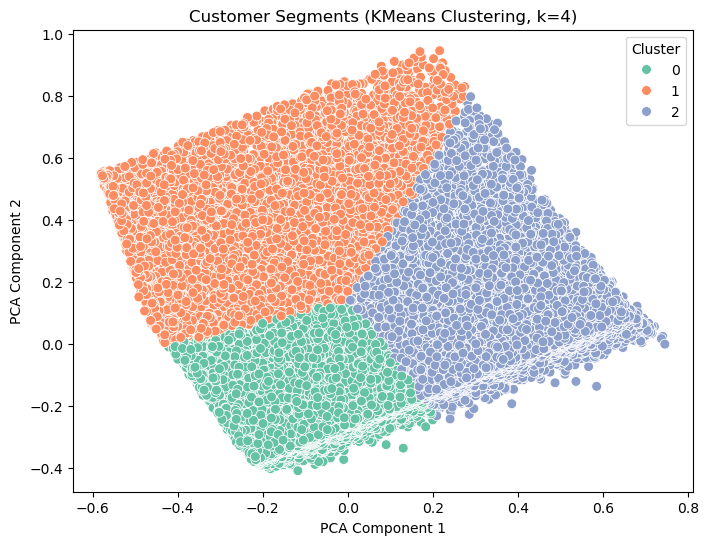

In [52]:
from sklearn.decomposition import PCA

# Predict cluster labels for the scaled data using the baseline KMeans model
pred_labels = kmeans_baseline.predict(data_scaled)

# Add cluster labels to the dataframe for visualization
data_scaled_with_labels = data_scaled.copy()
data_scaled_with_labels['Cluster'] = pred_labels

# Plot clusters using the first two principal components for visualization

pca = PCA(n_components=2)
components = pca.fit_transform(data_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=pred_labels, palette='Set2', s=50)
plt.title('Customer Segments (KMeans Clustering, k=4)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

In [53]:
data_scaled_with_labels.head()

,L,R,F,M,C,Cluster
0,0.762044,0.000000,0.985782,1.000000,0.641093,2
1,0.726562,0.008219,0.654028,0.505403,0.834876,2
2,0.732422,0.013699,0.630332,0.488230,0.836450,2
3,0.547526,0.131507,0.099526,0.484136,0.727246,2
4,0.472331,0.005479,0.710900,0.533403,0.647105,2


In [54]:
data_clusters = pd.concat([data, data_scaled_with_labels['Cluster']], axis=1)
data_clusters.head()

,L,R,F,M,C,Cluster
0,2706.0,1.0,210.0,580717.0,0.961639,2.0
1,2597.0,7.0,140.0,293678.0,1.252314,2.0
2,2615.0,11.0,135.0,283712.0,1.254676,2.0
3,2047.0,97.0,23.0,281336.0,1.090870,2.0
4,1816.0,5.0,152.0,309928.0,0.970658,2.0


In [55]:
data_clusters.groupby('Cluster').mean()

,L,R,F,M,C
Cluster,,,,,
0.0,1489.476454,162.230406,12.302444,17767.029833,0.726591
1.0,1386.027906,255.295587,5.024985,6780.303813,0.682729
2.0,1541.949382,145.686937,15.529470,22808.073416,0.739148


- Cluster 0: Medium Length, Medium Recency, Medium Frequency, Medium Monetary, Medium Discount
- Cluster 1: Low Length, High Recency, Low Frequency, Low Monetary, Low Discount
- Cluster 2: High Length, Low Recency, High Frequency, High Monetary, High Discount

## Bussiness Recomendation

1. Cluster 0 (middle value customers):
- Upsell and cross-sell: Offer complementary or premium versions of products they already buy.
- Mid-tier loyalty programs: Provide incentives like point accumulation or small rewards to encourage repeat purchases.
- Personalized communication: Send curated product suggestions based on past activity or preferences.

2. Cluster 1 (low value customers):
- First-purchase incentives: Offer limited-time discounts to nudge them into action.
- Awareness and education campaigns: Use email or social media to introduce benefits and build trust
- Retargeting: Apply targeted advertising or reminder emails to bring them back to your platform.

3. Cluster 2 (high value customers):
- Exclusive benefits: Give them early access to new products, premium services, or special events.
- Relationship building: Assign account managers or create a VIP tier for personal outreach and support.
- Feedback loops: Gather their opinions via surveys to improve your offering and strengthen loyalty